> ### Note on Labs and Assignments:
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action!
>
> These sections are graded and are not optional.
>

# IS 4487 Lab 12: Naive Bayes, SVM, and Neural Networks

## Outline

- Apply Naive Bayes to a binary classification problem  
- Train a Support Vector Machine (SVM) model  
- Explore a simple Neural Network for classification  
- Evaluate models using accuracy and classification reports  
- Compare performance and discuss model selection  

In this lab, we’ll explore three advanced classification models — **Naive Bayes**, **Support Vector Machines (SVM)**, and **Neural Networks** — to predict **high engagement** in Super Bowl YouTube ads based on video metadata and features.

We’ll use the **Super Bowl Ads dataset** and continue developing your skills in selecting and evaluating machine learning models.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/lab_12_bayes_svm_neural.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Superbowl Ads: Business Context

The dataset for this lab consists of YouTube metadata and thematic features of Super Bowl commercials.  

This dataset captures Super Bowl advertisements and their performance on YouTube, providing a valuable business context around marketing effectiveness and audience engagement. Super Bowl ads are some of the most expensive and high-profile advertisements in the world, so companies are highly interested in understanding what makes an ad successful. The variables in this dataset describe both the content of the ads (such as whether they are funny, include celebrities, use animals, or feature patriotic themes) and their performance outcomes (like views, likes, comments, and overall engagement). Businesses can use this data to analyze which creative elements are associated with higher audience engagement—for example, whether humorous ads or celebrity appearances lead to more likes or shares. By using the high_engagement variable as a target, analysts can even build predictive models to determine what combination of features is most likely to result in a successful ad. Insights from this type of analysis can help marketing teams design more effective campaigns, allocate advertising budgets more strategically, and maximize the return on their investment in major events like the Super Bowl.

Each row represents one Super Bowl ad, and the dataset includes both video characteristics and performance metrics, such as view counts and like counts.


## Data Dictionary
Source: [TidyTuesday (March 2, 2021)](https://github.com/rfordatascience/tidytuesday/blob/master/data/2021/2021-03-02/youtube.csv).

| Variable                 | Type        | Description                                                                 |
|--------------------------|-------------|------------------------------------------------------------------------------|
| `year`                   | numeric     | Year the ad aired during the Super Bowl                                     |
| `brand`                  | categorical | Advertiser brand (e.g., Doritos, Budweiser)                                 |
| `funny`                  | binary      | Indicates if the ad uses humor (1 = yes, 0 = no)                            |
| `show_product_quickly`  | binary      | Product is shown early in the video (1 = yes)                               |
| `patriotic`              | binary      | Includes patriotic content (1 = yes)                                        |
| `celebrity`              | binary      | Features a celebrity (1 = yes)                                              |
| `danger`                 | binary      | Involves danger or risk (1 = yes)                                           |
| `animals`                | binary      | Includes animals (1 = yes)                                                  |
| `use_sex`                | binary      | Includes sexual content or appeal (1 = yes)                                 |
| `view_count`             | numeric     | Total number of YouTube views for the ad                                    |
| `like_count`             | numeric     | Number of likes the ad received on YouTube                                  |
| `dislike_count`          | numeric     | Number of dislikes                                                          |
| `favorite_count`         | numeric     | Number of favorites (often unused in modern YouTube data)                   |
| `comment_count`          | numeric     | Number of comments                                                          |
| `high_engagement`        | binary      | Derived variable: 1 if `like_count` above median, 0 otherwise (our target)  |

### Why this dataset?

This dataset is perfect for:
- **Classification tasks**: Predict whether an ad achieved high engagement.
- **Marketing insights**: Identify which ad traits (e.g., humor, celebrities) drive viewer responses.
- **Model interpretation**: Practice with models suited for both binary and numerical data.

Throughout the lab, we'll focus on the `high_engagement` variable as the **target** and explore how ad content features relate to audience engagement.


## Part 1: Load and Clean the Data

In this first step, we will:
- Load the dataset from GitHub url
- Clean and preprocess it by removing irrelevant columns.
- Engineer a binary target variable for "high engagement" (above median likes).

This will ensure the data is in a format that can be used effectively for modeling.


In [1]:
import pandas as pd
import numpy as np

# Load dataset
url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/youtube.csv'
youtube = pd.read_csv(url)

# Drop irrelevant or complex API columns
youtube = youtube.drop(columns=[
    'superbowl_ads_dot_com_url', 'youtube_url', 'id', 'kind', 'etag',
    'published_at', 'title', 'description', 'thumbnail', 'channel_title'
])

# Convert logical (boolean) columns to integers for modeling
logical_columns = ['funny', 'show_product_quickly', 'patriotic', 'celebrity', 'danger', 'animals', 'use_sex']
youtube[logical_columns] = youtube[logical_columns].astype(int)

# Drop rows with missing like_count
youtube = youtube.dropna(subset=['like_count', 'view_count'])

# Create target: high_engagement
median_likes = youtube['like_count'].median()
youtube['high_engagement'] = (youtube['like_count'] > median_likes).astype(int)


# Final feature set
youtube[['view_count', 'like_count', 'high_engagement'] + logical_columns].head()

,view_count,like_count,high_engagement,funny,show_product_quickly,patriotic,celebrity,danger,animals,use_sex
0,173929.0,1233.0,1,0,0,0,0,0,0,0
1,47752.0,485.0,1,1,1,0,1,1,0,0
2,142310.0,129.0,0,1,0,0,0,1,1,0
3,198.0,2.0,0,0,1,0,0,0,0,0
4,13741.0,20.0,0,1,1,0,0,1,1,1


## Part 2: Naive Bayes Classifier

Naive Bayes is a **probabilistic model** based on Bayes' Theorem. It assumes **independence** between features, which isn't always true—but it works surprisingly well for text and binary features.

We'll use the boolean ad features (like `funny`, `celebrity`, etc.) to predict whether the video had high engagement.

Ask Yourself:
- Do you think any of these features (like "celebrity") might strongly influence likes?
- How might the independence assumption affect the predictions?

Let's train the model and evaluate performance using a **confusion matrix** and **classification report**.


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Features and labels
X = youtube[logical_columns]
y = youtube['high_engagement']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit model
nb_model = BernoulliNB()
nb_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_nb = nb_model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print("Accuracy:", accuracy_score(y_test, y_pred_nb))

Confusion Matrix:
 [[19 19]
 [16 14]]

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.50      0.52        38
           1       0.42      0.47      0.44        30

    accuracy                           0.49        68
   macro avg       0.48      0.48      0.48        68
weighted avg       0.49      0.49      0.49        68

Accuracy: 0.4852941176470588


### 🔧 Try It Yourself — Part 2

1. **Change the test size** to `0.2`. How does this affect accuracy?  
   > Update `train_test_split(test_size=0.2)` and rerun the model.

2. **Remove `celebrity` and `funny` features** from X. Rerun the model and check performance.  
   > Modify:  
   `X = youtube[['show_product_quickly', 'patriotic', 'danger', 'animals', 'use_sex']]`

### In Your Response:

1. Which model setup performed best? Why might that be?


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# --- First modification: Change test_size to 0.2 ---
# Original features
# X = youtube[logical_columns]
# y = youtube['high_engagement']

# Train-test split with test_size=0.2
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
# nb_model = BernoulliNB()
# nb_model.fit(X_train, y_train)

# Predict and evaluate
# y_pred_nb = nb_model.predict(X_test)

# print("Confusion Matrix (test_size=0.2):\n", confusion_matrix(y_test, y_pred_nb))
# print("\nClassification Report (test_size=0.2):\n", classification_report(y_test, y_pred_nb))
# print("Accuracy (test_size=0.2):", accuracy_score(y_test, y_pred_nb))

# --- Second modification: Remove 'celebrity' and 'funny' features from X ---
logical_columns_modified = ['show_product_quickly', 'patriotic', 'danger', 'animals', 'use_sex']
X_modified = youtube[logical_columns_modified]
y_modified = youtube['high_engagement']

# Train-test split with test_size=0.2 and modified features
X_train_modified, X_test_modified, y_train_modified, y_test_modified = train_test_split(X_modified, y_modified, test_size=0.2, random_state=42)

# Fit model with modified features
nb_model_modified = BernoulliNB()
nb_model_modified.fit(X_train_modified, y_train_modified)

# Predict and evaluate with modified features
y_pred_nb_modified = nb_model_modified.predict(X_test_modified)

print("Confusion Matrix (modified features, test_size=0.2):\n", confusion_matrix(y_test_modified, y_pred_nb_modified))
print("\nClassification Report (modified features, test_size=0.2):\n", classification_report(y_test_modified, y_pred_nb_modified))
print("Accuracy (modified features, test_size=0.2):", accuracy_score(y_test_modified, y_pred_nb_modified))

Confusion Matrix (modified features, test_size=0.2):
 [[13 14]
 [ 9  9]]

Classification Report (modified features, test_size=0.2):
               precision    recall  f1-score   support

           0       0.59      0.48      0.53        27
           1       0.39      0.50      0.44        18

    accuracy                           0.49        45
   macro avg       0.49      0.49      0.48        45
weighted avg       0.51      0.49      0.49        45

Accuracy (modified features, test_size=0.2): 0.4888888888888889


### ✍️ Your Response: 🔧
1. The modified setup preformed better than the original set up. The diffrence was small, but noticable. The reason the modified set up preformed better was due to the removal of nosiy variables that did not contribute to the data.

## Part 3: Support Vector Machine (SVM)

### What you're going to do:
Use a **Support Vector Machine** to classify ads, using both binary and numeric features.

The SVM section begins by selecting the input features and target, then splitting the data into training and test sets to ensure fair evaluation. The features are scaled using a StandardScaler fit only on the training data so that all variables are on a comparable scale, which is important for SVM performance.

A support vector machine model is then trained on the scaled training data, optionally using cross-validation to tune hyperparameters like the kernel and regularization strength.

Finally, the trained model is used to make predictions on the untouched test set, and its performance is evaluated using metrics such as accuracy and a confusion matrix.

### Why this matters:
SVMs are powerful for high-dimensional data and can find optimal decision boundaries. They are also common in fraud detection and image recognition.

### Regularization Parameter (C):

- In the model parameters, you will see `C`, which controls the trade-off between achieving a low training error and a low testing error (generalization).

- A large `C` value (e.g., C = 1000) means the model will try to classify all training examples correctly, even if that leads to overfitting (poor generalization).

- A small `C` value (e.g., C = 0.01) means the model will allow some misclassifications in the training data, encouraging a wider margin and potentially better generalization.

### What to notice:
- How does scaling the data affect performance?
- What happens when you change the kernel or regularization?

In [4]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

X = youtube[logical_columns + ['view_count']]
y = youtube['high_engagement']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("Accuracy:", accuracy_score(y_test, y_pred_svm))


Confusion Matrix:
 [[25  9]
 [13 21]]

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.74      0.69        34
           1       0.70      0.62      0.66        34

    accuracy                           0.68        68
   macro avg       0.68      0.68      0.68        68
weighted avg       0.68      0.68      0.68        68

Accuracy: 0.6764705882352942


### 🔧 Try It Yourself — Part 3

1. **Change the kernel** to `'linear'` or `'poly'`.  
2. **Try 2 different `C` values** like `0.1`, `1`, and `10`. Observe what changes.

### In Your Response:
1. What’s the tradeoff between higher and lower values of `C`?
2. Which value of C gave you the best Accuracy?  


In [5]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# --- Experiment 1: Linear kernel, C=0.1 ---
print("\n--- SVM with Linear Kernel (C=0.1) ---")
svm_model_linear_c01 = SVC(kernel='linear', C=0.1, random_state=42)
svm_model_linear_c01.fit(X_train_scaled, y_train)
y_pred_svm_linear_c01 = svm_model_linear_c01.predict(X_test_scaled)

print("Confusion Matrix (C=0.1):\n", confusion_matrix(y_test, y_pred_svm_linear_c01))
print("\nClassification Report (C=0.1):\n", classification_report(y_test, y_pred_svm_linear_c01))
print("Accuracy (C=0.1):", accuracy_score(y_test, y_pred_svm_linear_c01))

# --- Experiment 2: Linear kernel, C=10 ---
print("\n--- SVM with Linear Kernel (C=10) ---")
svm_model_linear_c10 = SVC(kernel='linear', C=10, random_state=42)
svm_model_linear_c10.fit(X_train_scaled, y_train)
y_pred_svm_linear_c10 = svm_model_linear_c10.predict(X_test_scaled)

print("Confusion Matrix (C=10):\n", confusion_matrix(y_test, y_pred_svm_linear_c10))
print("\nClassification Report (C=10):\n", classification_report(y_test, y_pred_svm_linear_c10))
print("Accuracy (C=10):", accuracy_score(y_test, y_pred_svm_linear_c10))


--- SVM with Linear Kernel (C=0.1) ---
Confusion Matrix (C=0.1):
 [[26  8]
 [25  9]]

Classification Report (C=0.1):
               precision    recall  f1-score   support

           0       0.51      0.76      0.61        34
           1       0.53      0.26      0.35        34

    accuracy                           0.51        68
   macro avg       0.52      0.51      0.48        68
weighted avg       0.52      0.51      0.48        68

Accuracy (C=0.1): 0.5147058823529411

--- SVM with Linear Kernel (C=10) ---
Confusion Matrix (C=10):
 [[33  1]
 [20 14]]

Classification Report (C=10):
               precision    recall  f1-score   support

           0       0.62      0.97      0.76        34
           1       0.93      0.41      0.57        34

    accuracy                           0.69        68
   macro avg       0.78      0.69      0.67        68
weighted avg       0.78      0.69      0.67        68

Accuracy (C=10): 0.6911764705882353


### ✍️ Your Response: 🔧
1. The diffrence between a higer and low C values is the training error of the tests. A higher C value results in a more accurate model with narrow margians. A lover C values has a larger margian with less accuracy.
2. The test that used a C value of 10 gave the higest accruracy. This value was 0.6912. The lower C values of 0.1 gave an accuracy of 0.5174

## Part 4: Neural Networks

### What you're going to do:
The neural network script takes raw data and turns it into a trained and evaluated model.

First, it defines the input features (X) and the target variable (y). Then, it splits the dataset into three parts: a training set used to learn the model, a validation set used to monitor performance during training, and a test set reserved for final evaluation. After splitting, the features are scaled using a StandardScaler, which is fit only on the training data and then applied to the validation and test sets to keep everything consistent without introducing leakage.

Next, the neural network is built using a series of dense layers, ending with a sigmoid output for binary classification. The model is then compiled, specifying how it will learn (optimizer), how errors are measured (loss function), and what metrics to track. During training, the model learns from the training data while periodically evaluating itself on the validation set to track progress and detect overfitting. Once training is complete, the model makes predictions on the untouched test set, and its performance is evaluated using metrics like accuracy, a confusion matrix, and a classification report. This entire flow ensures that the model is trained properly and evaluated fairly on data it has never seen before.

We will use the `Scaler` to transform big numbers, like `view_count` into a small range, with the average value as 0 and each standard deviation is 1.  

### Why this matters:
Neural networks are the foundation of modern AI. Even a simple one can outperform traditional models when tuned correctly.

### What to notice:
- This may take several minutes to run!  Be patient.
- How does training accuracy compare to validation accuracy?
- Do more layers or epochs help — or hurt?


In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Build features and target from the raw dataframe again
X_nn = youtube[logical_columns + ['view_count']]
y_nn = youtube['high_engagement']

# Hold out the final test set first
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_nn, y_nn, test_size=0.30, random_state=42, stratify=y_nn
)

# Split training data into train + true validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=42, stratify=y_train_full
)

# Fit a fresh scaler on NN training data only
nn_scaler = StandardScaler()
X_train = nn_scaler.fit_transform(X_train)
X_val = nn_scaler.transform(X_val)
X_test = nn_scaler.transform(X_test)

# Build the neural net with 4 layers
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train with the neural net with the real validation split
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=16,
    verbose=1
)

#  Do a final evaluation only on untouched test data
y_pred_nn = (model.predict(X_test) > 0.5).astype(int).ravel()

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nn))
print("Accuracy:", accuracy_score(y_test, y_pred_nn))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.4560 - loss: 0.7238 - val_accuracy: 0.5000 - val_loss: 0.7254
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4480 - loss: 0.7170 - val_accuracy: 0.4688 - val_loss: 0.7223
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4480 - loss: 0.7117 - val_accuracy: 0.4688 - val_loss: 0.7197
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4480 - loss: 0.7074 - val_accuracy: 0.4688 - val_loss: 0.7177
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4560 - loss: 0.7047 - val_accuracy: 0.5000 - val_loss: 0.7155
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4560 - loss: 0.7010 - val_accuracy: 0.5312 - val_loss: 0.7141
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4800 - loss: 0.6984 - val_accuracy: 0.5312 - val_loss: 0.7132
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4720 - loss: 0.6960 - val_accuracy: 0.5312 - val_loss: 0.7130


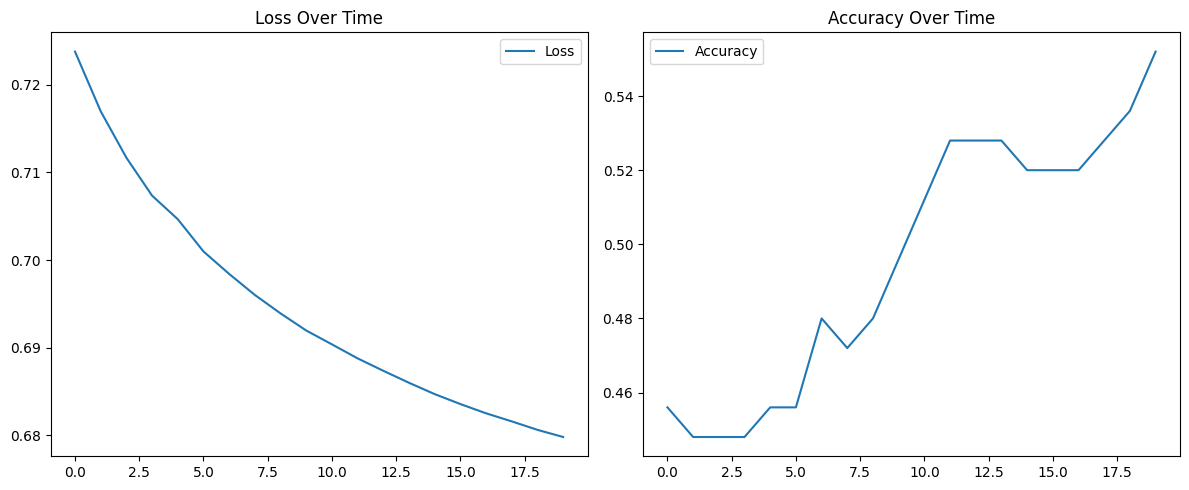

In [7]:
# Plot learning curves
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.title('Loss Over Time')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.title('Accuracy Over Time')
plt.legend()
plt.tight_layout()
plt.show()

### 🔧 Try It Yourself — Part 4

1. Add or remove layers from the model.
2. Increase or decrease batch size to numbers such as 8 or 32. Try out 5 different combinations of different batch sizes and layers. Notice if these changes affect ms/step for each Epoch. Also notice how the accuracy changes as you alter layers and batch size.
3. Add Dropout to your model

### In Your Response:
1. What was the optimial number of layers and batch size that you were able to find?  (Remember, you should try about 5 different combinations)
2. Does adding `Dropout` help reduce overfitting? Use the "loss over time" plot to support your answer.



--- Running Experiment: Exp 1: Base (3 hidden layers, Batch 16, No Dropout) ---
Hidden Layers: 3, Batch Size: 16, Dropout Rate: 0.0
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.4800 - loss: 0.7050 - val_accuracy: 0.5625 - val_loss: 0.6956
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5040 - loss: 0.7010 - val_accuracy: 0.5625 - val_loss: 0.6953
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5120 - loss: 0.6986 - val_accuracy: 0.5625 - val_loss: 0.6946
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5200 - loss: 0.6967 - val_accuracy: 0.5312 - val_loss: 0.6943
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5200 - loss: 0.6945 - val_accuracy: 0.5312 - val_loss: 0.6943
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5200 - loss: 0.6930 - val_accuracy: 0.5312 - val_loss: 0.6943
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5280 - loss: 0.6918 - val_accuracy: 0.5312 - val_loss: 0.6940
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5280 - loss: 0.6903 - val_accuracy: 0.5312 - val_loss: 0.6939
Epoch 9/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.4560 - loss: 0.7537 - val_accuracy: 0.5625 - val_loss: 0.6331
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4560 - loss: 0.7457 - val_accuracy: 0.5625 - val_loss: 0.6342
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4560 - loss: 0.7400 - val_accuracy: 0.5625 - val_loss: 0.6351
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4640 - loss: 0.7339 - val_accuracy: 0.5625 - val_loss: 0.6365
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4640 - loss: 0.7293 - val_accuracy: 0.5625 - val_loss: 0.6375
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4640 - loss: 0.7245 - val_accuracy: 0.5625 - val_loss: 0.6387
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4640 - loss: 0.7203 - val_accuracy: 0.5625 - val_loss: 0.6401
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4720 - loss: 0.7162 - val_accuracy: 0.5625 - val_loss: 0.6412
Epoch 9/20


...

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5200 - loss: 0.7157 - val_accuracy: 0.4688 - val_loss: 0.7229
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5280 - loss: 0.7043 - val_accuracy: 0.4688 - val_loss: 0.7185
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5360 - loss: 0.6965 - val_accuracy: 0.4688 - val_loss: 0.7176
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5360 - loss: 0.6908 - val_accuracy: 0.4688 - val_loss: 0.7170
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5680 - loss: 0.6853 - val_accuracy: 0.5312 - val_loss: 0.7141
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6160 - loss: 0.6808 - val_accuracy: 0.5312 - val_loss: 0.7136
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6080 - loss: 0.6769 - val_accuracy: 0.5625 - val_loss: 0.7139
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6240 - loss: 0.6717 - val_accuracy: 0.5000 - val_loss: 0.7146
Ep

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.4960 - loss: 0.7138 - val_accuracy: 0.4062 - val_loss: 0.7158
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4880 - loss: 0.7101 - val_accuracy: 0.4375 - val_loss: 0.7141
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4960 - loss: 0.7068 - val_accuracy: 0.4375 - val_loss: 0.7134
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5040 - loss: 0.7043 - val_accuracy: 0.4375 - val_loss: 0.7123
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5040 - loss: 0.7022 - val_accuracy: 0.4688 - val_loss: 0.7111
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5200 - loss: 0.7000 - val_accuracy: 0.4688 - val_loss: 0.7106
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5040 - loss: 0.6982 - val_accuracy: 0.4375 - val_loss: 0.7110
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5280 - loss: 0.6966 - val_accuracy: 0.4375 - val_loss: 0.7107
Epoch 9/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.5120 - loss: 0.7164 - val_accuracy: 0.5000 - val_loss: 0.7123
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5280 - loss: 0.6883 - val_accuracy: 0.5312 - val_loss: 0.7088
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4640 - loss: 0.7248 - val_accuracy: 0.5312 - val_loss: 0.7061
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5280 - loss: 0.7231 - val_accuracy: 0.5312 - val_loss: 0.7040
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5280 - loss: 0.7013 - val_accuracy: 0.5312 - val_loss: 0.7019
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5600 - loss: 0.7014 - val_accuracy: 0.5000 - val_loss: 0.7006
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4800 - loss: 0.7043 - val_accuracy: 0.5000 - val_loss: 0.6993
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5200 - loss: 0.7118 - val_accuracy: 0.5312 - val_loss: 0.6987
Epoch 9/20


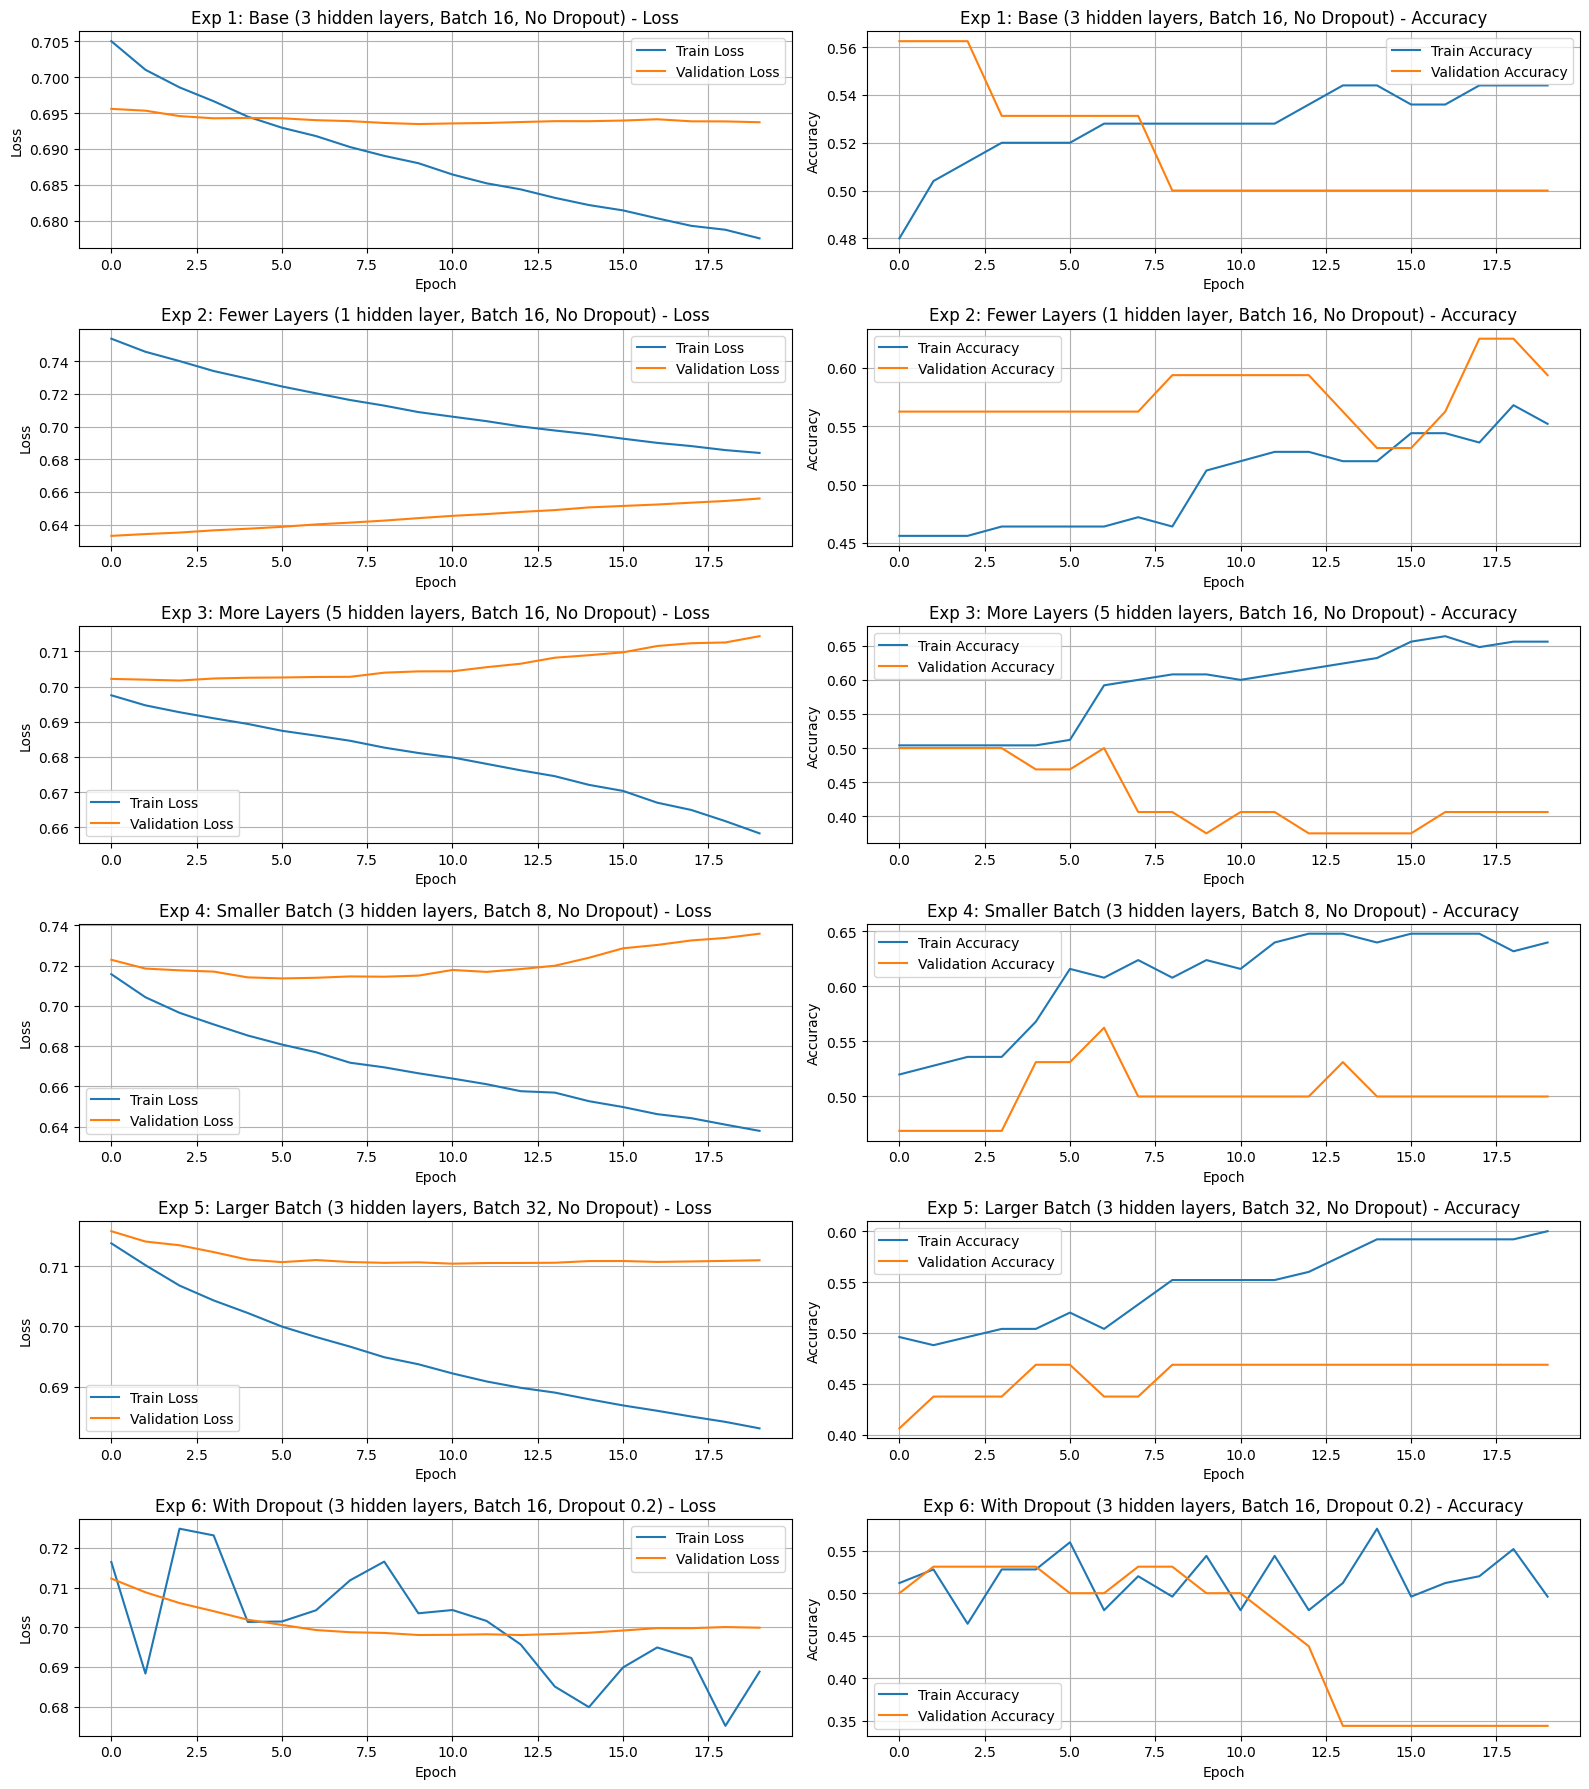

In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np # Used for plotting

# Make sure X_train, y_train, X_val, y_val, X_test, y_test are available from the previous cell.

# Define a function to run an experiment with given parameters
def run_nn_experiment(X_train, y_train, X_val, y_val, X_test, y_test, num_hidden_layers, batch_size, dropout_rate, experiment_name):
    print(f"\n--- Running Experiment: {experiment_name} ---")
    print(f"Hidden Layers: {num_hidden_layers}, Batch Size: {batch_size}, Dropout Rate: {dropout_rate}")

    model = Sequential()
    # First hidden layer (input layer)
    model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    # Additional hidden layers
    for _ in range(num_hidden_layers - 1): # -1 because the first hidden layer is already added
        model.add(Dense(8, activation='relu')) # Fixed units for subsequent layers for simpler comparison
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Train the neural network
    # verbose=1 to observe ms/step for each Epoch
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=20, # Keeping epochs consistent for comparison
        batch_size=batch_size,
        verbose=1 # Display verbose output to observe ms/step
    )

    # Evaluate on untouched test data
    y_pred_nn = (model.predict(X_test, verbose=0) > 0.5).astype(int).ravel() # Suppress prediction verbose
    accuracy = accuracy_score(y_test, y_pred_nn)

    print(f"Test Accuracy for {experiment_name}: {accuracy:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nn))
    print("\nClassification Report:\n", classification_report(y_test, y_pred_nn))
    print("-" * 70)
    return accuracy, history

# Experiment combinations
# num_hidden_layers refers to the number of Dense layers BEFORE the final output layer.
# The first Dense layer will have 16 units, subsequent ones will have 8 units for simplicity.
experiments_config = [
    {"num_hidden_layers": 3, "batch_size": 16, "dropout_rate": 0.0, "name": "Exp 1: Base (3 hidden layers, Batch 16, No Dropout)"},
    {"num_hidden_layers": 1, "batch_size": 16, "dropout_rate": 0.0, "name": "Exp 2: Fewer Layers (1 hidden layer, Batch 16, No Dropout)"},
    {"num_hidden_layers": 5, "batch_size": 16, "dropout_rate": 0.0, "name": "Exp 3: More Layers (5 hidden layers, Batch 16, No Dropout)"},
    {"num_hidden_layers": 3, "batch_size": 8, "dropout_rate": 0.0, "name": "Exp 4: Smaller Batch (3 hidden layers, Batch 8, No Dropout)"},
    {"num_hidden_layers": 3, "batch_size": 32, "dropout_rate": 0.0, "name": "Exp 5: Larger Batch (3 hidden layers, Batch 32, No Dropout)"},
    {"num_hidden_layers": 3, "batch_size": 16, "dropout_rate": 0.2, "name": "Exp 6: With Dropout (3 hidden layers, Batch 16, Dropout 0.2)"}
]

all_results = []
all_histories = {}

for exp in experiments_config:
    acc, hist = run_nn_experiment(
        X_train, y_train, X_val, y_val, X_test, y_test,
        exp["num_hidden_layers"], exp["batch_size"], exp["dropout_rate"], exp["name"]
    )
    all_results.append({"name": exp["name"], "accuracy": acc})
    all_histories[exp["name"]] = hist

print("\n--- Summary of All Neural Network Experiments ---")
for res in all_results:
    print(f"{res['name']}: Test Accuracy = {res['accuracy']:.4f}")

# Plotting learning curves for all experiments
plt.figure(figsize=(16, len(all_histories) * 3)) # Adjust figure size dynamically

for i, (name, history_obj) in enumerate(all_histories.items()):
    # Plot Loss
    plt.subplot(len(all_histories), 2, 2*i + 1)
    plt.plot(history_obj.history['loss'], label='Train Loss')
    plt.plot(history_obj.history['val_loss'], label='Validation Loss')
    plt.title(f'{name} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracy
    plt.subplot(len(all_histories), 2, 2*i + 2)
    plt.plot(history_obj.history['accuracy'], label='Train Accuracy')
    plt.plot(history_obj.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{name} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

### ✍️ Your Response: 🔧
1. After running the code, I found that the optiamal number of layers and batch size was 1 layer, and 16 btaches. This gave me the best accuracy— this number was 0.6471
2. From analyizing the data, I found that adding dropout did not help in improving the accruacy of the test. In a diffrent secerio, dropout could have improved that accruacy, but it had a minimal effect in this case.

## 🔧 Part 5: Reflection (100 words or less per question)

1. Which model performed best on your dataset? Is this the result you expected?
2. Did any of the models appear to be overfit or underfit? How could you tell?
3. Which model would you recommend to a marketing team and why?

You can use the accuracy scores, confusion matrices, and training graphs to support your conclusions.


### ✍️ Your Response: 🔧
1. Looking back on the models, I found that the SVM model has the best results. It had an accuracy of 0.691. The nural network was close behind at 0.647. This is not neccicrily what I expected, but ut makes senses conisdering the dataset we are working with.
2. Yes, the Naive Bayes model strongly underpreformed when compared to the other models. The Bayes model had an accuracy of 0.489. This is almost 0.2 less than the other two models.
3. Based on the data I would recommed the SVM model to a marketing team. It had the higest accuracy, and is a very good model to use when working with large and complex datasets. The SVM model is very versitail and would serve the marketing team the best.

## Export Your Notebook to Submit in Canvas
- Use the instructions from Lab 1

In [9]:
!jupyter nbconvert --to html "lab_12_bayes_svm_neural_TettelbachIan.ipynb"

[NbConvertApp] Converting notebook lab_12_bayes_svm_neural_TettelbachIan.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 963510 bytes to lab_12_bayes_svm_neural_TettelbachIan.html
